In [1]:
import os
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

### Visualize train and validation loss and Reconstruction and KL Loss during training

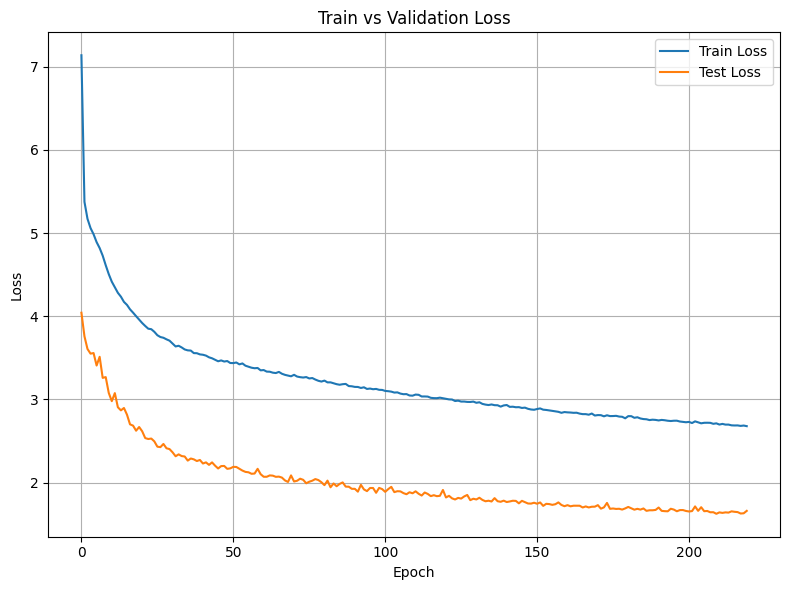

In [3]:
ZOOM = False
IDX = 110

df = pd.read_csv("logs_512/loss_log.csv")
epochs = df["epoch"]

if ZOOM:
    plt.figure(figsize=(8, 6))
    plt.plot(epochs[IDX:], df["train_loss"][IDX:], label="Train Loss")
    plt.plot(epochs[IDX:], df["test_loss"][IDX:], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, df.iloc[:,3], label="Train Loss")
    plt.plot(epochs, df.iloc[:,4], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Visualize mean and logvariance of the validation set

In [4]:
def load_all_latents(latents_dir):
    files = sorted(os.listdir(latents_dir), key=lambda f: int(re.findall(r'\d+', f)[0]))
    latents = []

    for f in files:
        data = torch.load(os.path.join(latents_dir, f))
        epoch = int(re.findall(r'\d+', f)[0])
        latents.append({"epoch": epoch, "mu": data["mu"], "logvar": data["logvar"]})
    
    return latents

In [5]:
SAVE_FOLDER = "logs"
latents = load_all_latents(f"{SAVE_FOLDER}/latents")
print(f"Loaded {len(latents)} epochs of latent codes.")

FileNotFoundError: [Errno 2] No such file or directory: 'logs/latents'

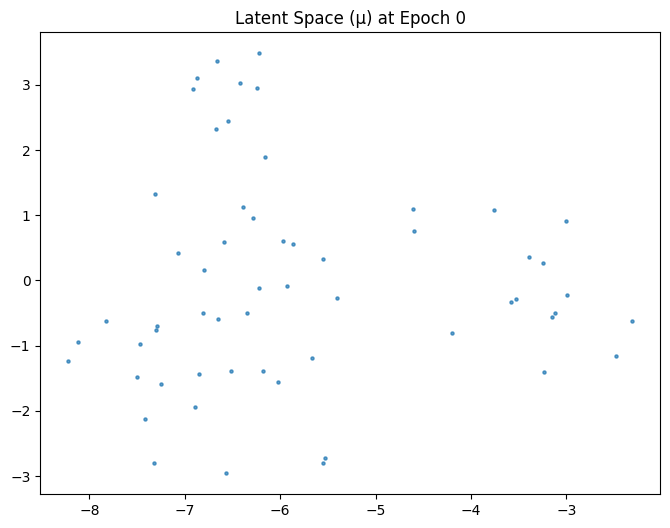

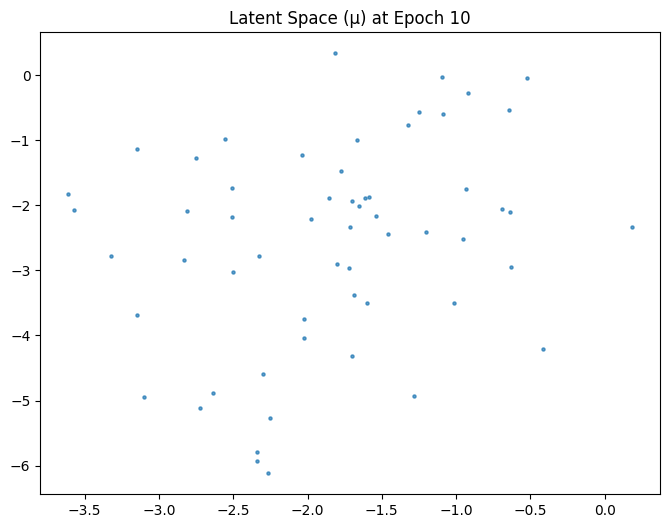

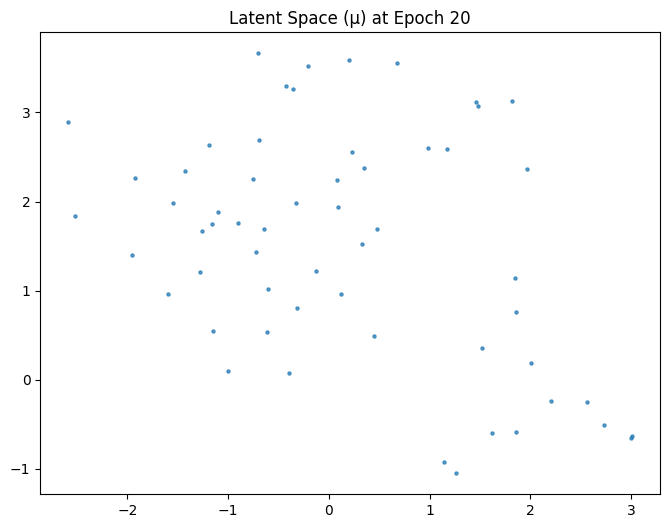

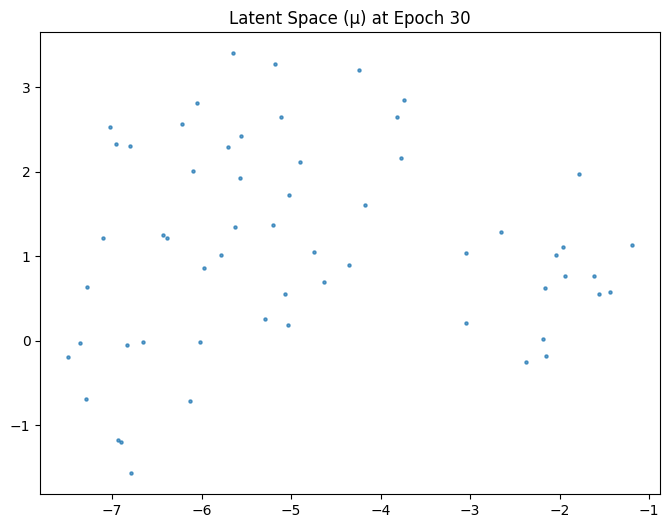

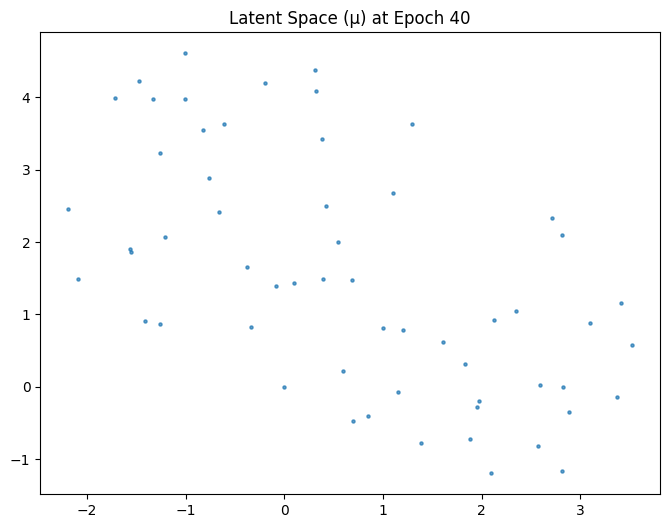

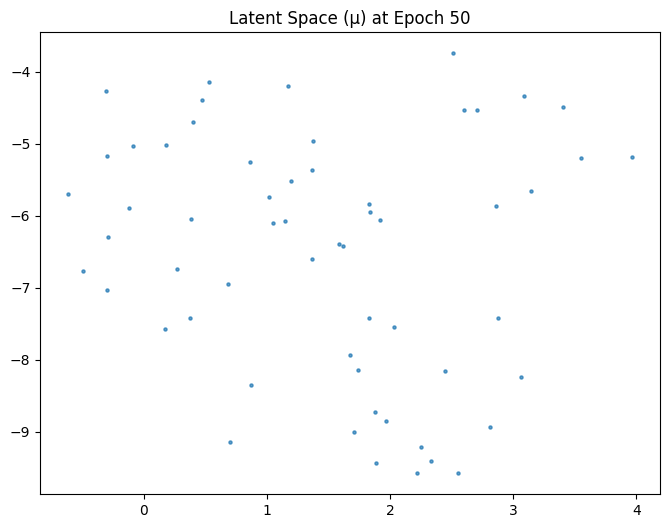

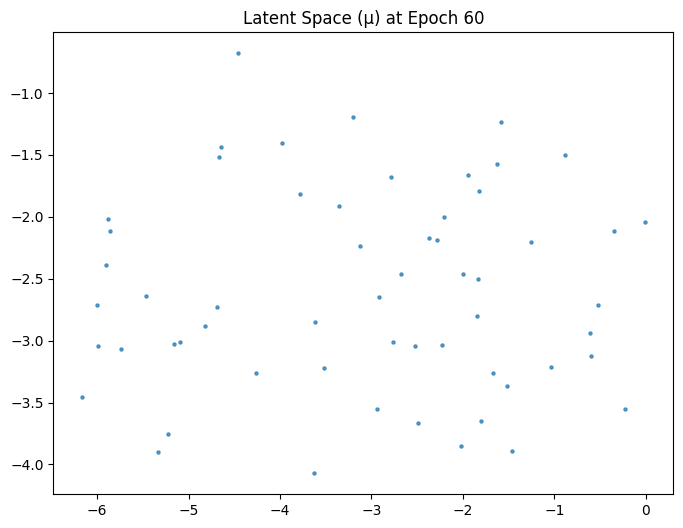

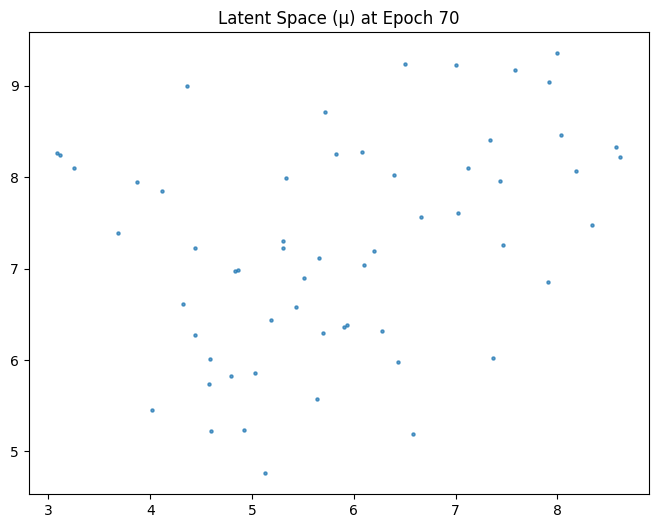

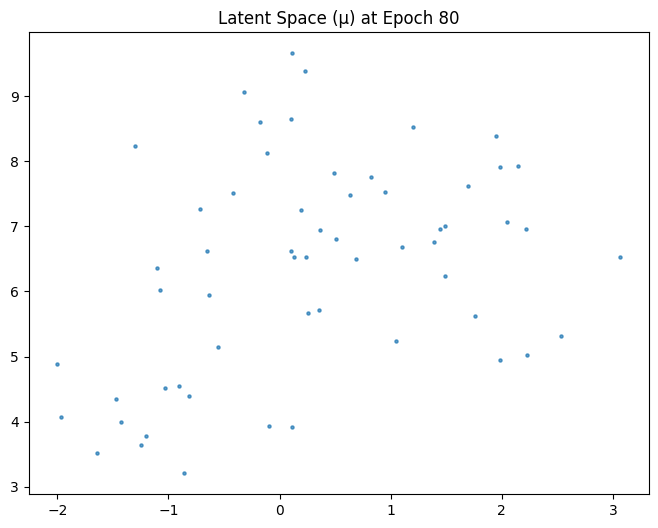

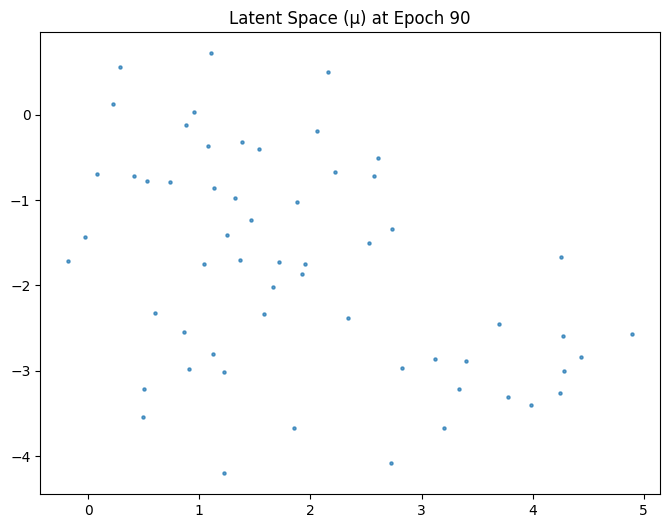

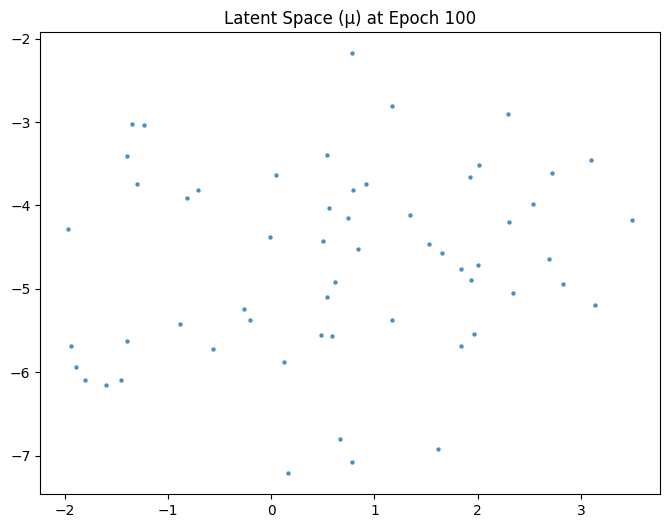

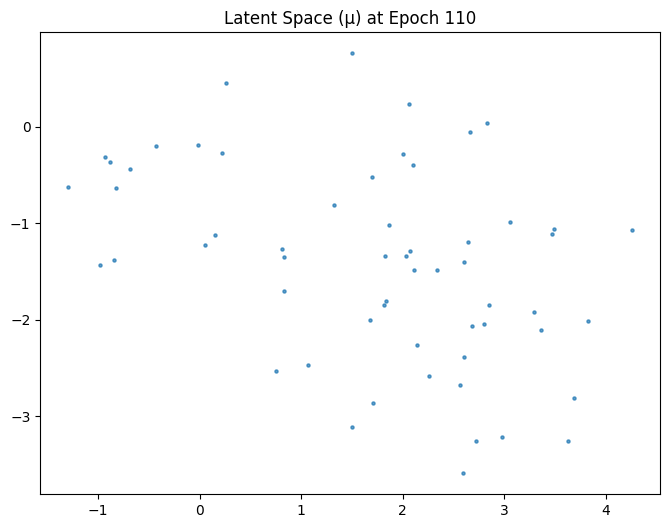

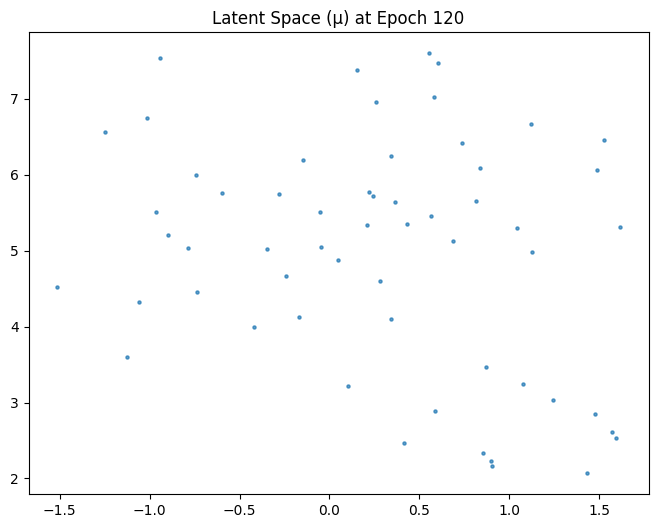

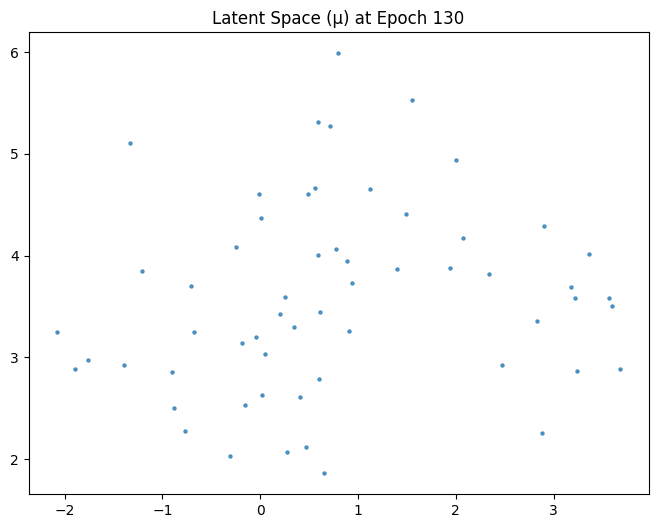

In [7]:
for i in range(0, len(latents), 10):  # every 10 epochs
    mu = latents[i]["mu"]
    z_embedded = TSNE(n_components=2).fit_transform(mu.numpy())

    plt.figure(figsize=(8, 6))
    plt.scatter(z_embedded[:, 0], z_embedded[:, 1], s=5, alpha=0.7)
    plt.title(f"Latent Space (μ) at Epoch {latents[i]['epoch']}")
    plt.show()